In [1]:
# @title 1. Setup Environment, Hardware & Path
import sys
import os
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from tensorflow.keras import mixed_precision

# Setup tampilan Pandas agar tabel rapi
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 4)

# --- A. Mount Drive ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- B. Setup Path (SESUAIKAN JIKA PERLU) ---
BASE_DIR = '/content/drive/MyDrive/Skripsi/Deep_Learning'
DATASET_PATH = os.path.join(BASE_DIR, 'food-101')
IMAGE_DIR = os.path.join(DATASET_PATH, 'images')
META_DIR = os.path.join(DATASET_PATH, 'meta')
MODELS_DIR = os.path.join(BASE_DIR, 'models')

# Buat folder models jika belum ada
if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)

# Validasi Path
print(f"📂 BASE DIR: {BASE_DIR}")
if os.path.exists(IMAGE_DIR):
    num_folders = len(os.listdir(IMAGE_DIR))
    print(f"✅ Dataset Ditemukan: {IMAGE_DIR}")
    print(f"📊 Jumlah Kelas Terdeteksi: {num_folders}")
else:
    print(f"❌ ERROR: Folder images tidak ditemukan di {IMAGE_DIR}")
    print("   Mohon cek kembali struktur folder di Google Drive.")

# --- C. Hardware Check & Optimization ---
def setup_hardware():
    print("\n🚀 MEMERIKSA HARDWARE & KONFIGURASI...")
    try:
        # Mixed Precision untuk efisiensi tinggi (Mempercepat training)
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed Precision Aktif: {policy.compute_dtype}")

        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            try:
                gpu_name = !nvidia-smi --query-gpu=gpu_name --format=csv,noheader
                print(f"✅ GPU Terdeteksi: {gpu_name[0]}")
            except:
                print("✅ GPU Terdeteksi (Detail nama tidak dapat diambil)")
            strategy = tf.distribute.MirroredStrategy()
        else:
            print("⚠️ GPU Tidak Terdeteksi. Training akan sangat lambat.")
            strategy = tf.distribute.get_strategy()
    except Exception as e:
        print(f"⚠️ Warning pada setup GPU: {e}")
        strategy = tf.distribute.get_strategy()

    print("\n🔰 SISTEM SIAP.")
    return strategy

strategy = setup_hardware()

📂 BASE DIR: /content/drive/MyDrive/Skripsi/Deep_Learning
✅ Dataset Ditemukan: /content/drive/MyDrive/Skripsi/Deep_Learning/food-101/images
📊 Jumlah Kelas Terdeteksi: 101

🚀 MEMERIKSA HARDWARE & KONFIGURASI...
✅ Mixed Precision Aktif: float16
✅ GPU Terdeteksi: NVIDIA A100-SXM4-80GB

🔰 SISTEM SIAP.


In [2]:
# @title 2. Data Loading Pipeline
import tensorflow as tf
import os

# --- KONFIGURASI ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

print(f"⚙️ PIPELINE CONFIG:\nImage Size : {IMG_SIZE}\nBatch Size : {BATCH_SIZE}\n")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Folder images tidak ditemukan di: {IMAGE_DIR}")

# 1. Training Set
print("Menyiapkan Training Set...")
# FIX: Panggil via tf.keras.utils
train_ds = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    verbose=1
)

# 2. Validation Set
print("\nMenyiapkan Validation Set...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    verbose=1
)

# Nama Kelas
loaded_class_names = train_ds.class_names
num_classes = len(loaded_class_names)
print(f"\n📊 Total Kelas Ter-load: {num_classes} Jenis Makanan")

# 3. Optimasi
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(256).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

⚙️ PIPELINE CONFIG:
Image Size : (224, 224)
Batch Size : 64

Menyiapkan Training Set...
Found 101000 files belonging to 101 classes.
Using 80800 files for training.

Menyiapkan Validation Set...
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.

📊 Total Kelas Ter-load: 101 Jenis Makanan


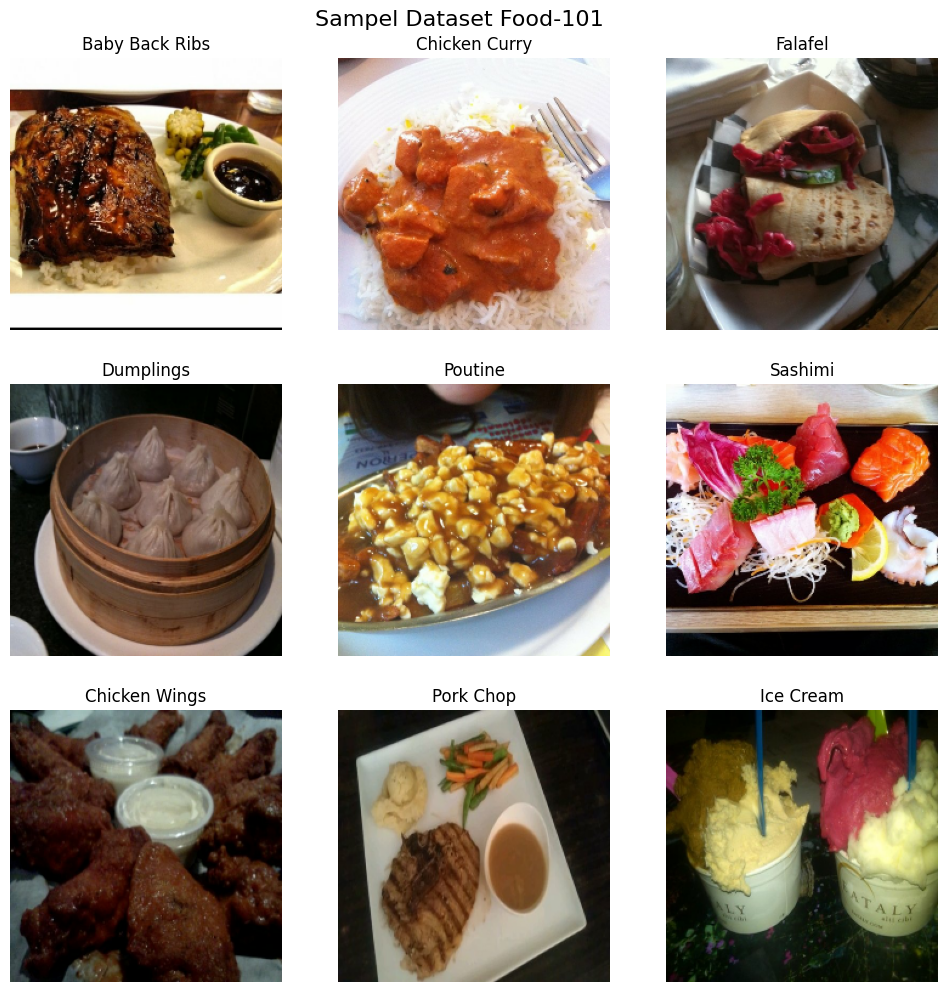

In [3]:
# @title 3. Visualisasi Sampel Dataset
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(12, 12))
plt.suptitle("Sampel Dataset Food-101", fontsize=16, y=0.92)

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = image_batch[i].numpy().astype("uint8")
    plt.imshow(img)

    label_index = np.argmax(label_batch[i])
    class_name = loaded_class_names[label_index].replace("_", " ").title()

    plt.title(class_name)
    plt.axis("off")

plt.show()

In [4]:
# @title 4. Membangun Model Arsitektur (EfficientNetV2B0)
import tensorflow as tf

def build_model(num_classes):
    # FIX: Gunakan tf.keras.layers
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))

    # Augmentasi Ringan
    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.1)(x)
    x = tf.keras.layers.RandomZoom(0.1)(x)

    # Base Model (EfficientNetV2B0)
    # FIX: Panggil langsung dari tf.keras.applications
    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        input_tensor=x,
        weights="imagenet"
    )

    base_model.trainable = True

    # Head
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Output
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return tf.keras.Model(inputs, outputs, name="EfficientNetV2B0_Food101")

with strategy.scope():
    model = build_model(num_classes)

print(f"✅ Model Arsitektur EfficientNetV2B0 Berhasil Dibangun untuk {num_classes} kelas.")
model.summary(expand_nested=True, show_trainable=True)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Model Arsitektur EfficientNetV2B0 Berhasil Dibangun untuk 101 kelas.


Model: "EfficientNetV2B0_Food101"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 224,     │         0 │ input_layer[0… │   -   │
│ (RandomFlip)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 224,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_zoom       │ (None, 224,     │         0 │ random_rotati… │   -   │
│ (RandomZoom)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 224,     │         0 │ random_zoom[0… │   -   │
│ (Rescaling)       │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ normalization     │ (None, 224,     │         0 │ rescaling[0][… │   -   │
│ (Normalization)   │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_conv         │ (None, 112,     │       864 │ normalization… │   Y   │
│ (Conv2D)          │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_bn           │ (None, 112,     │       128 │ stem_conv[0][… │   Y   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_activation   │ (None, 112,     │         0 │ stem_bn[0][0]  │   -   │
│ (Activation)      │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 112,     │     4,608 │ stem_activati… │   Y   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 112,     │        64 │ block1a_proje… │   Y   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 112,     │         0 │ block1a_proje… │   -   │
│ (Activation)      │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_expand_c… │ (None, 56, 56,  │     9,216 │ block1a_proje… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_expand_bn │ (None, 56, 56,  │       256 │ block2a_expan… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_expand_a… │ (None, 56, 56,  │         0 │ block2a_expan… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_project_… │ (None, 56, 56,  │     2,048 │ block2a_expan… │   Y   │
│ (Conv2D)          │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_project_… │ (None, 56, 56,  │       128 │ block2a_proje… │   Y 

 Total params: 6,053,813 (23.09 MB)

 Trainable params: 5,990,645 (22.85 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [5]:
# @title 5. Optimizer & Learning Rate Scheduler
import tensorflow as tf
import numpy as np

# FIX: Path lengkap untuk decorator
@tf.keras.utils.register_keras_serializable()
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
             raise ValueError("Total steps must be larger than warmup steps")
        lr = 0.5 * self.learning_rate_base * (1 + tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps) / float(self.total_steps - self.warmup_steps)))
        if self.warmup_steps > 0:
            slope = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)

    def get_config(self):
        return {'learning_rate_base': self.learning_rate_base, 'total_steps': self.total_steps, 'warmup_learning_rate': self.warmup_learning_rate, 'warmup_steps': self.warmup_steps}

# Config
EPOCHS = 15
steps_per_epoch = len(train_ds)
TOTAL_STEPS = int(steps_per_epoch * EPOCHS)
WARMUP_STEPS = int(TOTAL_STEPS * 0.1)

lr_schedule = WarmUpCosine(
    learning_rate_base=1e-4,
    total_steps=TOTAL_STEPS,
    warmup_learning_rate=1e-6,
    warmup_steps=WARMUP_STEPS
)

with strategy.scope():
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=2e-5)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=True
    )

print("✅ Model Berhasil di-Compile.")

✅ Model Berhasil di-Compile.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


In [ ]:
# @title 6. Start Training Process
import os
import tensorflow as tf

checkpoint_path = os.path.join(MODELS_DIR, 'best_model_efficientnet.keras')
log_path = os.path.join(MODELS_DIR, 'training_log.csv')

# --- Custom Callback: Mencatat Learning Rate (LR) ke training_log.csv ---
# Menambahkan nilai LR ke dict `logs` pada akhir setiap epoch.
# Harus dipanggil SEBELUM CSVLogger agar kolom 'lr' ikut tertulis di CSV.
class LearningRateLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        opt = self.model.optimizer
        lr = opt.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            step = opt.iterations
            lr_tensor = lr(step)
            current_lr = float(lr_tensor.numpy()) if hasattr(lr_tensor, 'numpy') else float(lr_tensor)
        else:
            current_lr = float(tf.keras.backend.get_value(lr))
        logs['lr'] = current_lr
        print(f"   📈 Epoch {epoch + 1} — Learning Rate: {current_lr:.2e}")

# FIX: Panggil callbacks langsung dari tf.keras.callbacks
# PENTING: LearningRateLogger harus SEBELUM CSVLogger agar kolom 'lr' ikut dicatat
callbacks = [
    LearningRateLogger(),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, min_delta=0.001),
    tf.keras.callbacks.CSVLogger(log_path)
]

print(f"🚀 MEMULAI TRAINING ({EPOCHS} Epochs)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training Selesai.")
print(f"📄 Log training (termasuk kolom LR) tersimpan di: {log_path}")

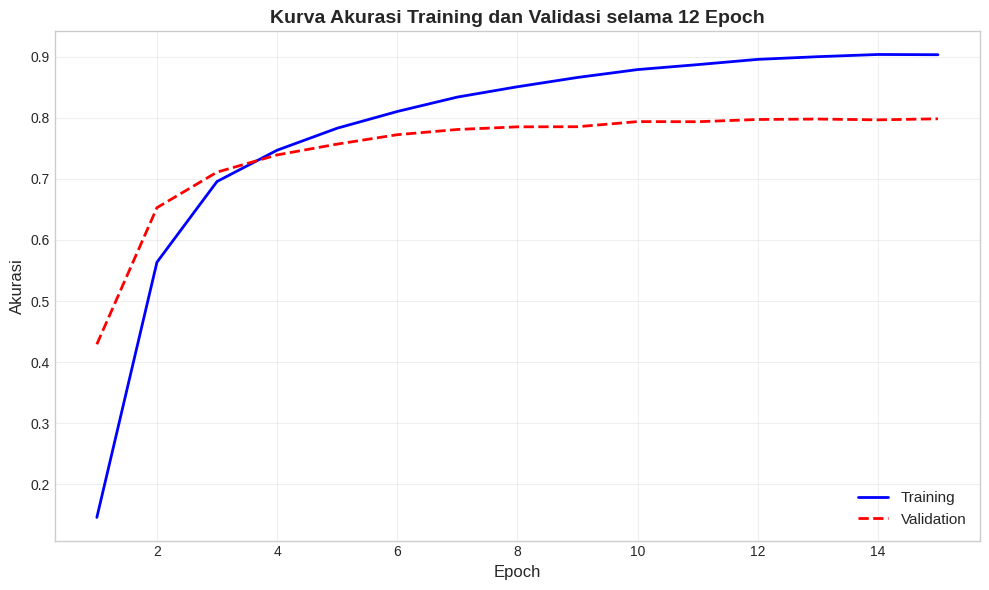

In [7]:
# @title 7a. Grafik Kurva Akurasi Training dan Validasi (Gambar 4.1)
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Ambil data dari history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)

# Plot tunggal: Akurasi
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, acc, label='Training', color='blue', linewidth=2)
ax.plot(epochs_range, val_acc, label='Validation', color='red', linestyle='--', linewidth=2)
ax.set_title('Kurva Akurasi Training dan Validasi selama 12 Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


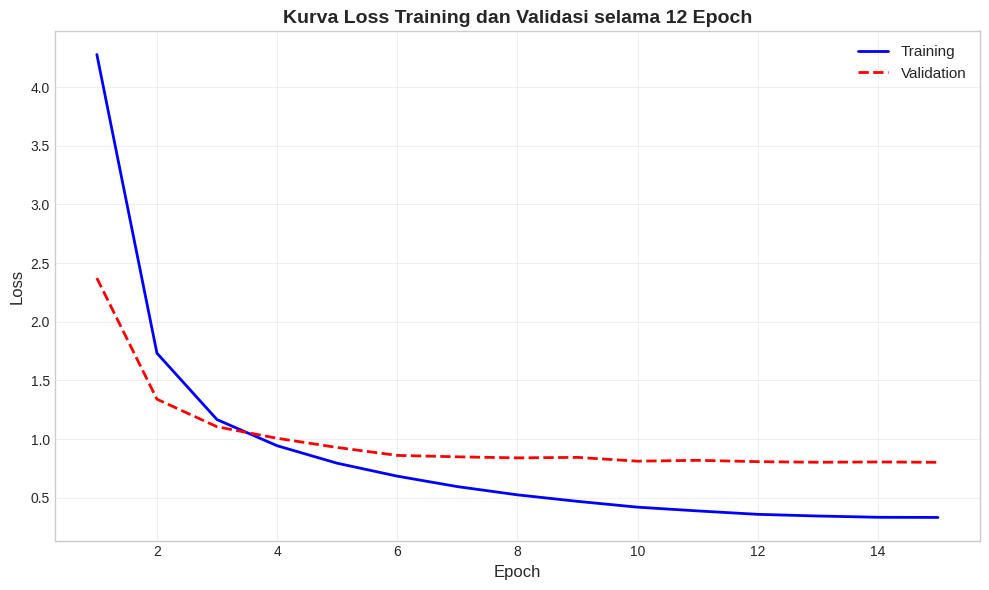

In [8]:
# @title 7b. Grafik Kurva Loss Training dan Validasi (Gambar 4.2)
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Ambil data dari history training
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

# Plot tunggal: Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, loss, label='Training', color='blue', linewidth=2)
ax.plot(epochs_range, val_loss, label='Validation', color='red', linestyle='--', linewidth=2)
ax.set_title('Kurva Loss Training dan Validasi selama 12 Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# @title 7c. Tabel Ringkasan Log Training per Epoch (termasuk Learning Rate)
import pandas as pd
import os

# Baca training_log.csv yang dihasilkan CSVLogger + LearningRateLogger (Cell 6)
log_path = os.path.join(MODELS_DIR, 'training_log.csv')

if not os.path.exists(log_path):
    print(f"❌ File tidak ditemukan: {log_path}")
else:
    df_log = pd.read_csv(log_path)

    # Normalisasi nama kolom: epoch mulai dari 1 (bukan 0)
    df_log['epoch'] = df_log['epoch'] + 1

    # Rename kolom menjadi lebih readable untuk skripsi
    rename_map = {
        'epoch': 'Epoch',
        'accuracy': 'Train Accuracy',
        'loss': 'Train Loss',
        'val_accuracy': 'Val Accuracy',
        'val_loss': 'Val Loss',
        'lr': 'Learning Rate'
    }
    df_log = df_log.rename(columns=rename_map)

    # Urutan kolom rapi sesuai kebutuhan skripsi
    ordered_cols = ['Epoch', 'Train Accuracy', 'Train Loss', 'Val Accuracy', 'Val Loss', 'Learning Rate']
    ordered_cols = [c for c in ordered_cols if c in df_log.columns]
    df_log = df_log[ordered_cols]

    # Format angka:
    # - Accuracy (0-1) → 4 desimal
    # - Loss           → 4 desimal
    # - Learning Rate  → scientific notation (contoh: 1.00e-04)
    styled = df_log.style.format({
        'Train Accuracy': '{:.4f}',
        'Train Loss':     '{:.4f}',
        'Val Accuracy':   '{:.4f}',
        'Val Loss':       '{:.4f}',
        'Learning Rate':  '{:.2e}'
    }).set_caption('Tabel 4.1 — Log Training per Epoch (EfficientNetV2B0)') \
      .set_properties(**{'text-align': 'center'}) \
      .set_table_styles([
          {'selector': 'th', 'props': [('background-color', '#8B9556'),
                                        ('color', 'white'),
                                        ('font-weight', 'bold'),
                                        ('text-align', 'center')]},
          {'selector': 'caption', 'props': [('caption-side', 'top'),
                                             ('font-weight', 'bold'),
                                             ('font-size', '1.05em'),
                                             ('padding', '8px')]}
      ])

    # Tampilkan tabel
    display(styled)

    # Juga print summary
    print(f"\n📊 Total Epoch: {len(df_log)}")
    print(f"📈 Best Val Accuracy: {df_log['Val Accuracy'].max():.4f} (Epoch {int(df_log.loc[df_log['Val Accuracy'].idxmax(), 'Epoch'])})")
    print(f"📉 Best Val Loss:     {df_log['Val Loss'].min():.4f} (Epoch {int(df_log.loc[df_log['Val Loss'].idxmin(), 'Epoch'])})")
    print(f"🎯 Learning Rate Range: {df_log['Learning Rate'].min():.2e} → {df_log['Learning Rate'].max():.2e}")

In [9]:
# @title 8. Evaluasi Model pada Validation Set
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("=" * 60)
print("  EVALUASI MODEL PADA VALIDATION SET")
print("=" * 60)

# --- A. Kumpulkan Seluruh Data Validasi ---
print("\n🔄 Mengumpulkan data validasi...")
val_images = []
val_labels = []
for img, label in val_ds.unbatch():
    val_images.append(img)
    val_labels.append(label)

val_images_np = np.array(val_images)
val_labels_np = np.array(val_labels)
print(f"✅ Total gambar validasi: {len(val_images_np)}")

# --- B. Prediksi ---
print("🔄 Menjalankan prediksi model...")
y_pred_probs = model.predict(val_images_np, batch_size=64, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(val_labels_np, axis=1)

# --- C. Akurasi Keseluruhan ---
overall_acc = np.mean(y_pred == y_true)
print(f"\n📊 Akurasi Keseluruhan (Overall Accuracy): {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print("=" * 60)

  EVALUASI MODEL PADA VALIDATION SET

🔄 Mengumpulkan data validasi...
✅ Total gambar validasi: 20200
🔄 Menjalankan prediksi model...
316/316 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step

📊 Akurasi Keseluruhan (Overall Accuracy): 0.7983 (79.83%)


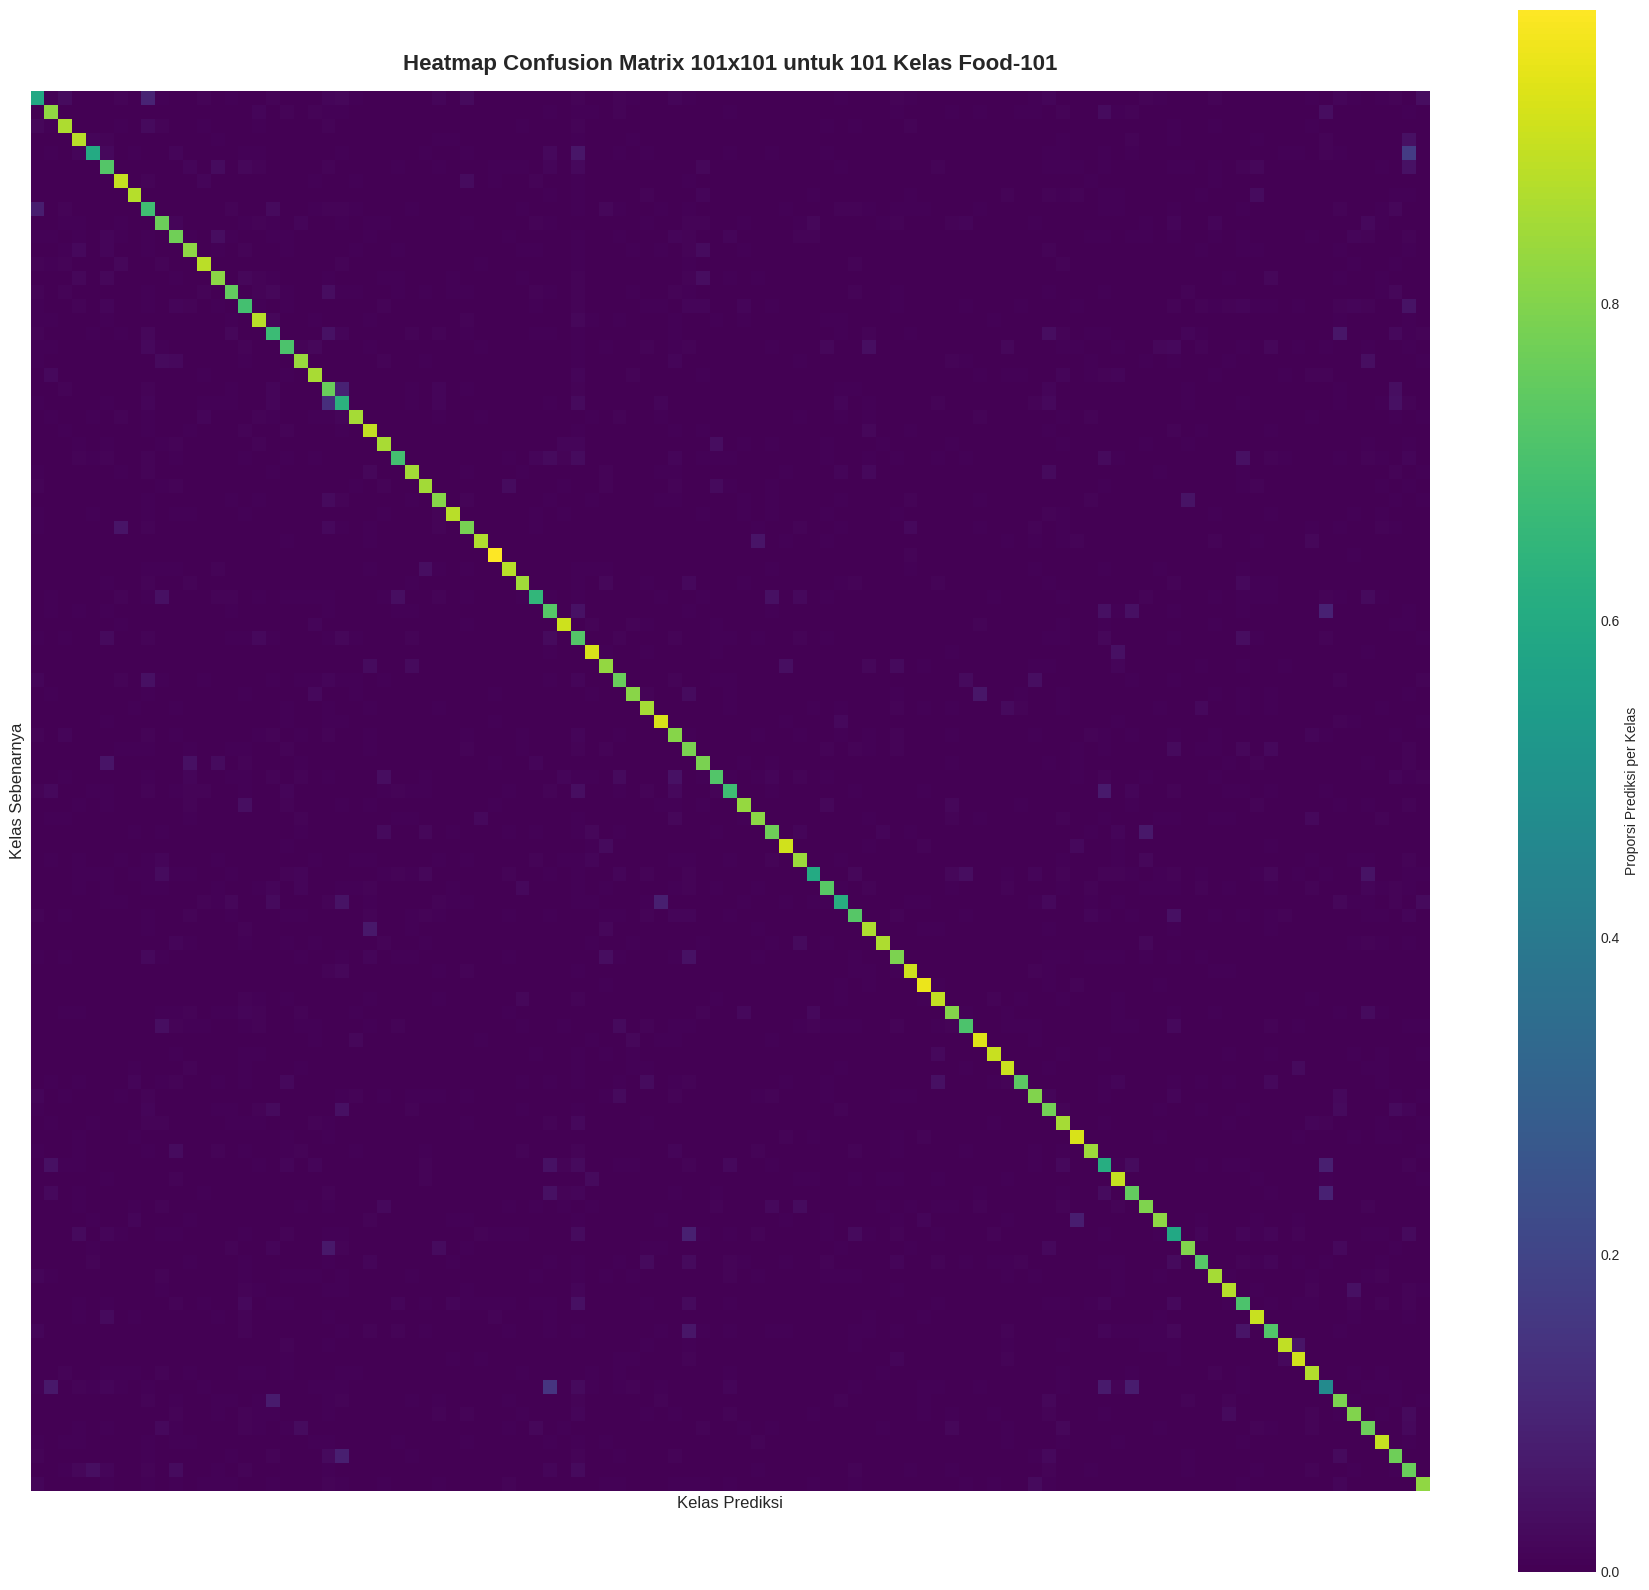


=== 10 Pasangan Kelas dengan Kesalahan Prediksi Tertinggi ===
 1. beef_tartare                   -> tuna_tartare                   : 34 kesalahan
 2. steak                          -> filet_mignon                   : 31 kesalahan
 3. chocolate_mousse               -> chocolate_cake                 : 26 kesalahan
 4. apple_pie                      -> bread_pudding                  : 20 kesalahan
 5. filet_mignon                   -> steak                          : 19 kesalahan
 6. prime_rib                      -> steak                          : 18 kesalahan
 7. chocolate_cake                 -> chocolate_mousse               : 18 kesalahan
 8. ravioli                        -> gnocchi                        : 17 kesalahan
 9. pork_chop                      -> steak                          : 17 kesalahan
10. tiramisu                       -> chocolate_mousse               : 16 kesalahan


In [10]:
# @title 8b. Heatmap Confusion Matrix 101x101 (Gambar 4.3)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix 101 x 101
cm = confusion_matrix(y_true, y_pred)

# Normalisasi per-baris (per kelas sebenarnya) agar skala seragam
cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

# Visualisasi heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_normalized,
    cmap='viridis',
    square=True,
    cbar_kws={'label': 'Proporsi Prediksi per Kelas'},
    xticklabels=False,
    yticklabels=False,
    ax=ax
)
ax.set_title('Heatmap Confusion Matrix 101x101 untuk 101 Kelas Food-101',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Prediksi', fontsize=12)
ax.set_ylabel('Kelas Sebenarnya', fontsize=12)

plt.tight_layout()
plt.show()

# Analisis kesalahan tertinggi (mendukung Tabel 4.3)
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
pairs = []
for i in range(cm_offdiag.shape[0]):
    for j in range(cm_offdiag.shape[1]):
        if cm_offdiag[i, j] > 0:
            pairs.append((cm_offdiag[i, j], loaded_class_names[i], loaded_class_names[j]))
pairs.sort(reverse=True)

print("\n=== 10 Pasangan Kelas dengan Kesalahan Prediksi Tertinggi ===")
for k, (cnt, true_cls, pred_cls) in enumerate(pairs[:10], 1):
    print(f"{k:2d}. {true_cls:30s} -> {pred_cls:30s} : {cnt} kesalahan")


In [11]:
# @title 9. Akurasi Per Kelas Makanan (Tabel Lengkap)
import pandas as pd
import numpy as np

print("=" * 60)
print("  AKURASI PER KELAS MAKANAN (101 KELAS)")
print("=" * 60)

# --- A. Hitung Akurasi Tiap Kelas ---
num_classes = len(loaded_class_names)
per_class_correct = np.zeros(num_classes)
per_class_total = np.zeros(num_classes)

for i in range(len(y_true)):
    true_label = y_true[i]
    per_class_total[true_label] += 1
    if y_pred[i] == true_label:
        per_class_correct[true_label] += 1

per_class_accuracy = per_class_correct / per_class_total

# --- B. Buat DataFrame Lengkap ---
df_accuracy = pd.DataFrame({
    'No': range(1, num_classes + 1),
    'Kelas Makanan': [name.replace('_', ' ').title() for name in loaded_class_names],
    'Label Asli': loaded_class_names,
    'Jumlah Sampel': per_class_total.astype(int),
    'Prediksi Benar': per_class_correct.astype(int),
    'Prediksi Salah': (per_class_total - per_class_correct).astype(int),
    'Akurasi (%)': np.round(per_class_accuracy * 100, 2)
})
df_accuracy = df_accuracy.set_index('No')

# --- C. Urutkan berdasarkan Akurasi (Tertinggi ke Terendah) ---
df_sorted = df_accuracy.sort_values(by='Akurasi (%)', ascending=False).reset_index(drop=True)
df_sorted.index = range(1, len(df_sorted) + 1)
df_sorted.index.name = 'Rank'

# --- D. Tampilkan Tabel Lengkap ---
pd.set_option('display.max_rows', 110)
print("\n📋 TABEL AKURASI SELURUH 101 KELAS (Diurutkan Tertinggi → Terendah):\n")
display(df_sorted[['Kelas Makanan', 'Jumlah Sampel', 'Prediksi Benar', 'Prediksi Salah', 'Akurasi (%)']])

# --- E. Statistik Ringkasan ---
print("\n" + "=" * 60)
print("  RINGKASAN STATISTIK AKURASI PER KELAS")
print("=" * 60)
print(f"  Rata-rata Akurasi   : {per_class_accuracy.mean()*100:.2f}%")
print(f"  Median Akurasi      : {np.median(per_class_accuracy)*100:.2f}%")
print(f"  Std. Deviasi        : {per_class_accuracy.std()*100:.2f}%")
print(f"  Akurasi Tertinggi   : {per_class_accuracy.max()*100:.2f}% ({loaded_class_names[np.argmax(per_class_accuracy)].replace('_',' ').title()})")
print(f"  Akurasi Terendah    : {per_class_accuracy.min()*100:.2f}% ({loaded_class_names[np.argmin(per_class_accuracy)].replace('_',' ').title()})")
print(f"  Kelas >= 90%        : {np.sum(per_class_accuracy >= 0.90)} kelas")
print(f"  Kelas >= 80%        : {np.sum(per_class_accuracy >= 0.80)} kelas")
print(f"  Kelas <  60%        : {np.sum(per_class_accuracy <  0.60)} kelas")
print("=" * 60)

  AKURASI PER KELAS MAKANAN (101 KELAS)

📋 TABEL AKURASI SELURUH 101 KELAS (Diurutkan Tertinggi → Terendah):



,Kelas Makanan,Jumlah Sampel,Prediksi Benar,Prediksi Salah,Akurasi (%)
Rank,,,,,
1,Edamame,201,198,3,98.51
2,Miso Soup,177,169,8,95.48
3,Onion Rings,194,181,13,93.30
4,Pho,204,189,15,92.65
5,French Fries,190,176,14,92.63
6,Frozen Yogurt,202,187,15,92.57
7,Hot And Sour Soup,190,174,16,91.58
8,Spaghetti Carbonara,195,178,17,91.28
9,Macarons,187,170,17,90.91



  RINGKASAN STATISTIK AKURASI PER KELAS
  Rata-rata Akurasi   : 79.94%
  Median Akurasi      : 81.25%
  Std. Deviasi        : 9.56%
  Akurasi Tertinggi   : 98.51% (Edamame)
  Akurasi Terendah    : 46.63% (Steak)
  Kelas >= 90%        : 13 kelas
  Kelas >= 80%        : 55 kelas
  Kelas <  60%        : 4 kelas


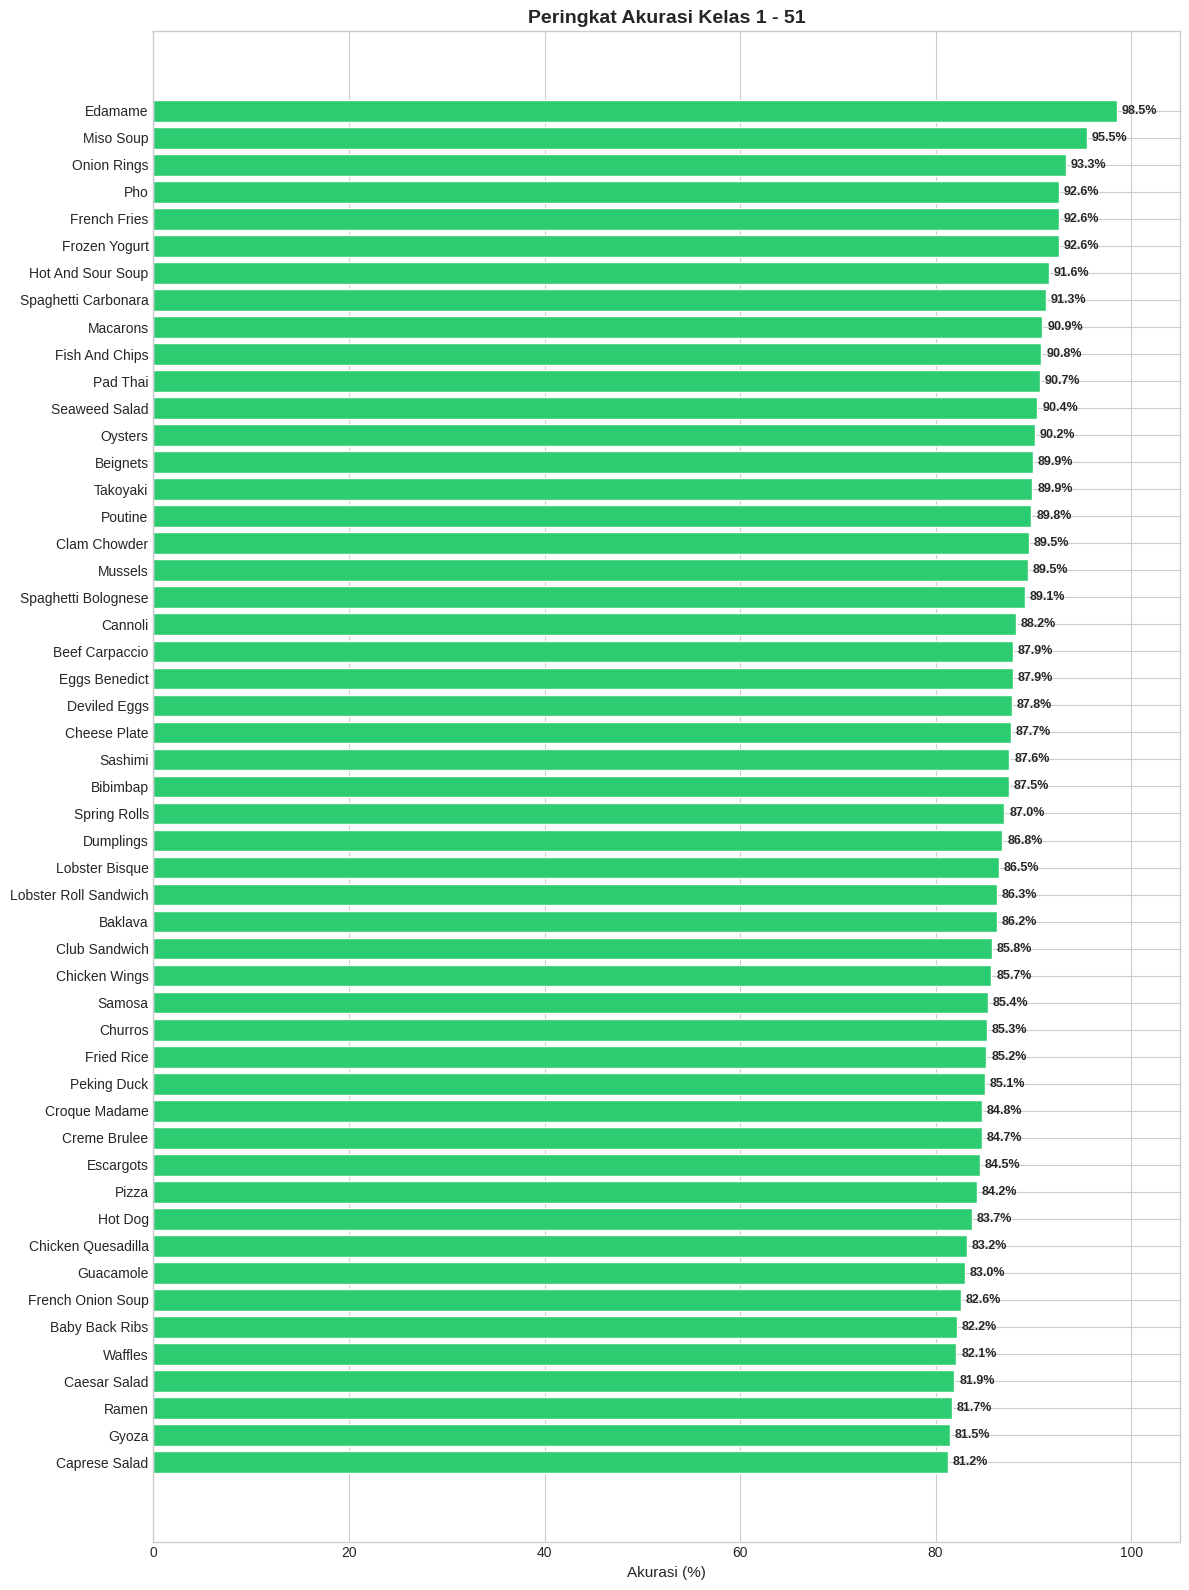

In [12]:
# @title 10a. Visualisasi Peringkat Akurasi Kelas 1 - 51
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]

# Kolom tunggal: Peringkat 1 - 51
fig, ax = plt.subplots(figsize=(12, 16))
bars = ax.barh(range(51), all_acc[:51], color='#2ecc71', edgecolor='white')
ax.set_yticks(range(51))
ax.set_yticklabels(all_names[:51], fontsize=10)
ax.set_xlabel('Akurasi (%)', fontsize=11)
ax.set_title('Peringkat Akurasi Kelas 1 - 51', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
ax.invert_yaxis()
for bar, val in zip(bars, all_acc[:51]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


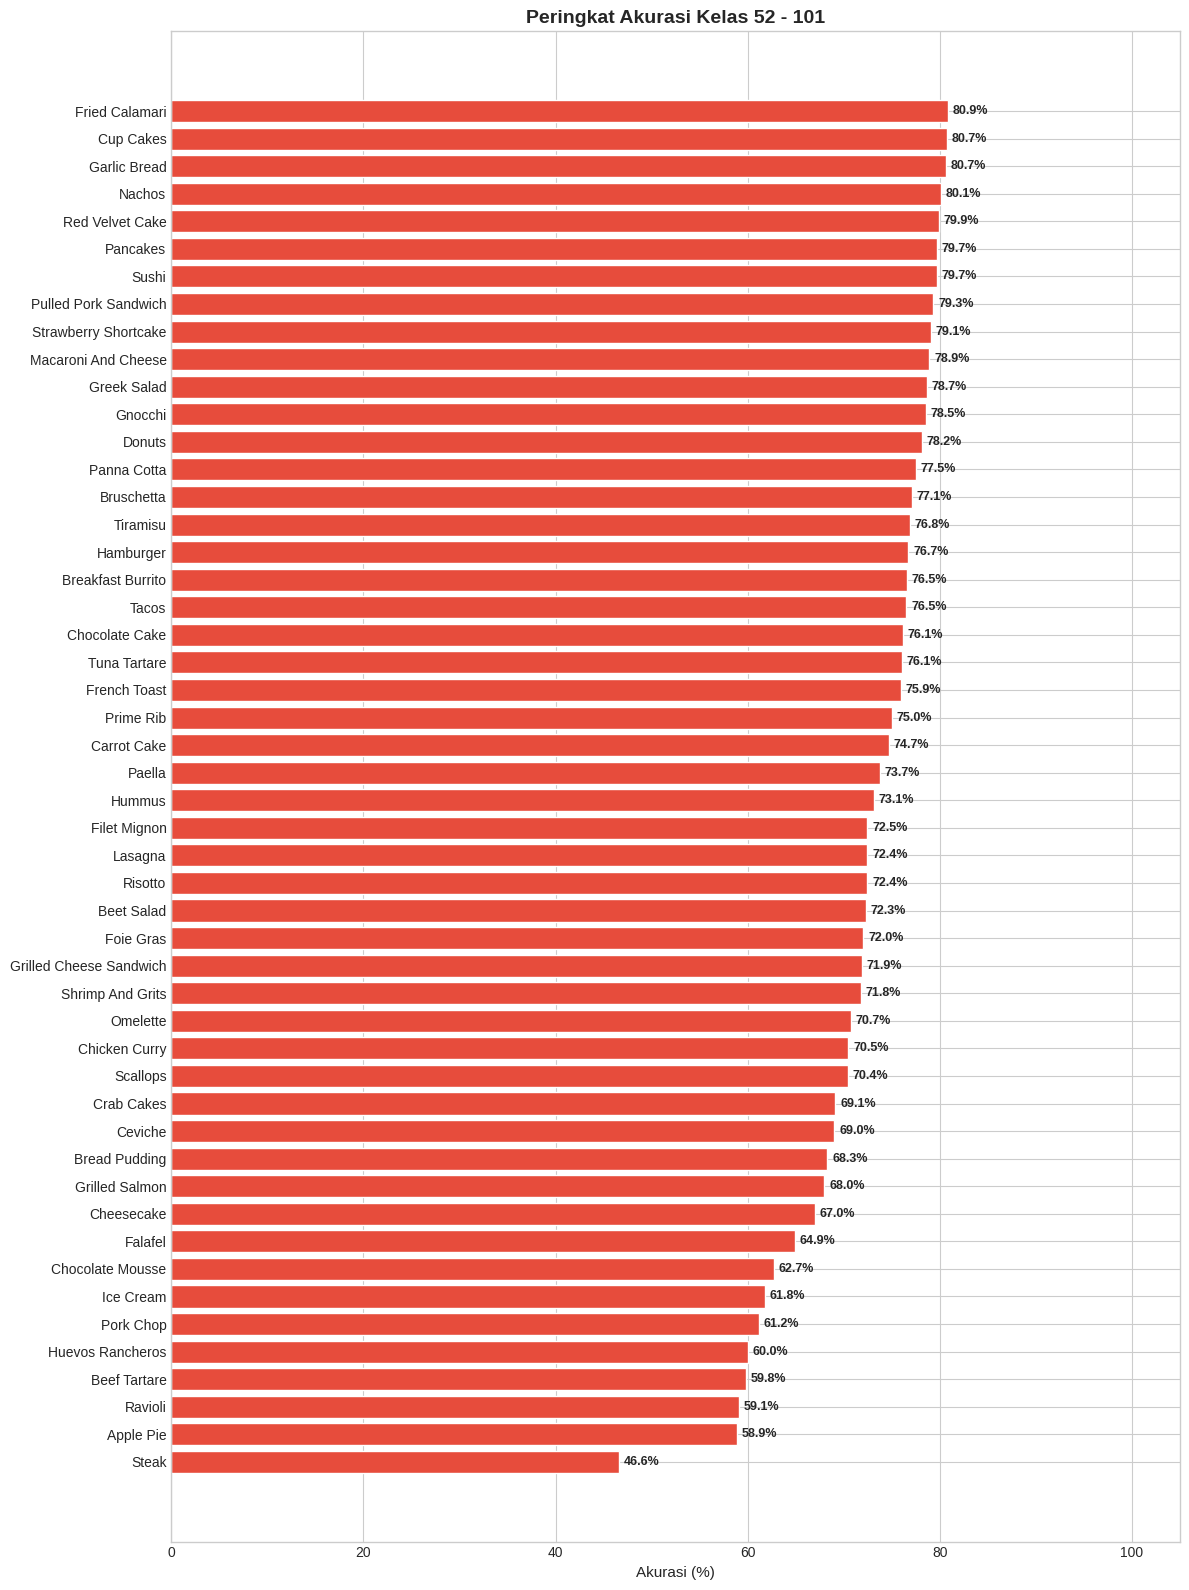

In [13]:
# @title 10b. Visualisasi Peringkat Akurasi Kelas 52 - 101
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]

sisa_kelas = len(all_acc) - 51
if sisa_kelas > 0:
    fig, ax = plt.subplots(figsize=(12, 16))
    bars = ax.barh(range(sisa_kelas), all_acc[51:], color='#e74c3c', edgecolor='white')
    ax.set_yticks(range(sisa_kelas))
    ax.set_yticklabels(all_names[51:], fontsize=10)
    ax.set_xlabel('Akurasi (%)', fontsize=11)
    ax.set_title(f'Peringkat Akurasi Kelas 52 - {len(all_acc)}', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()
    for bar, val in zip(bars, all_acc[51:]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()


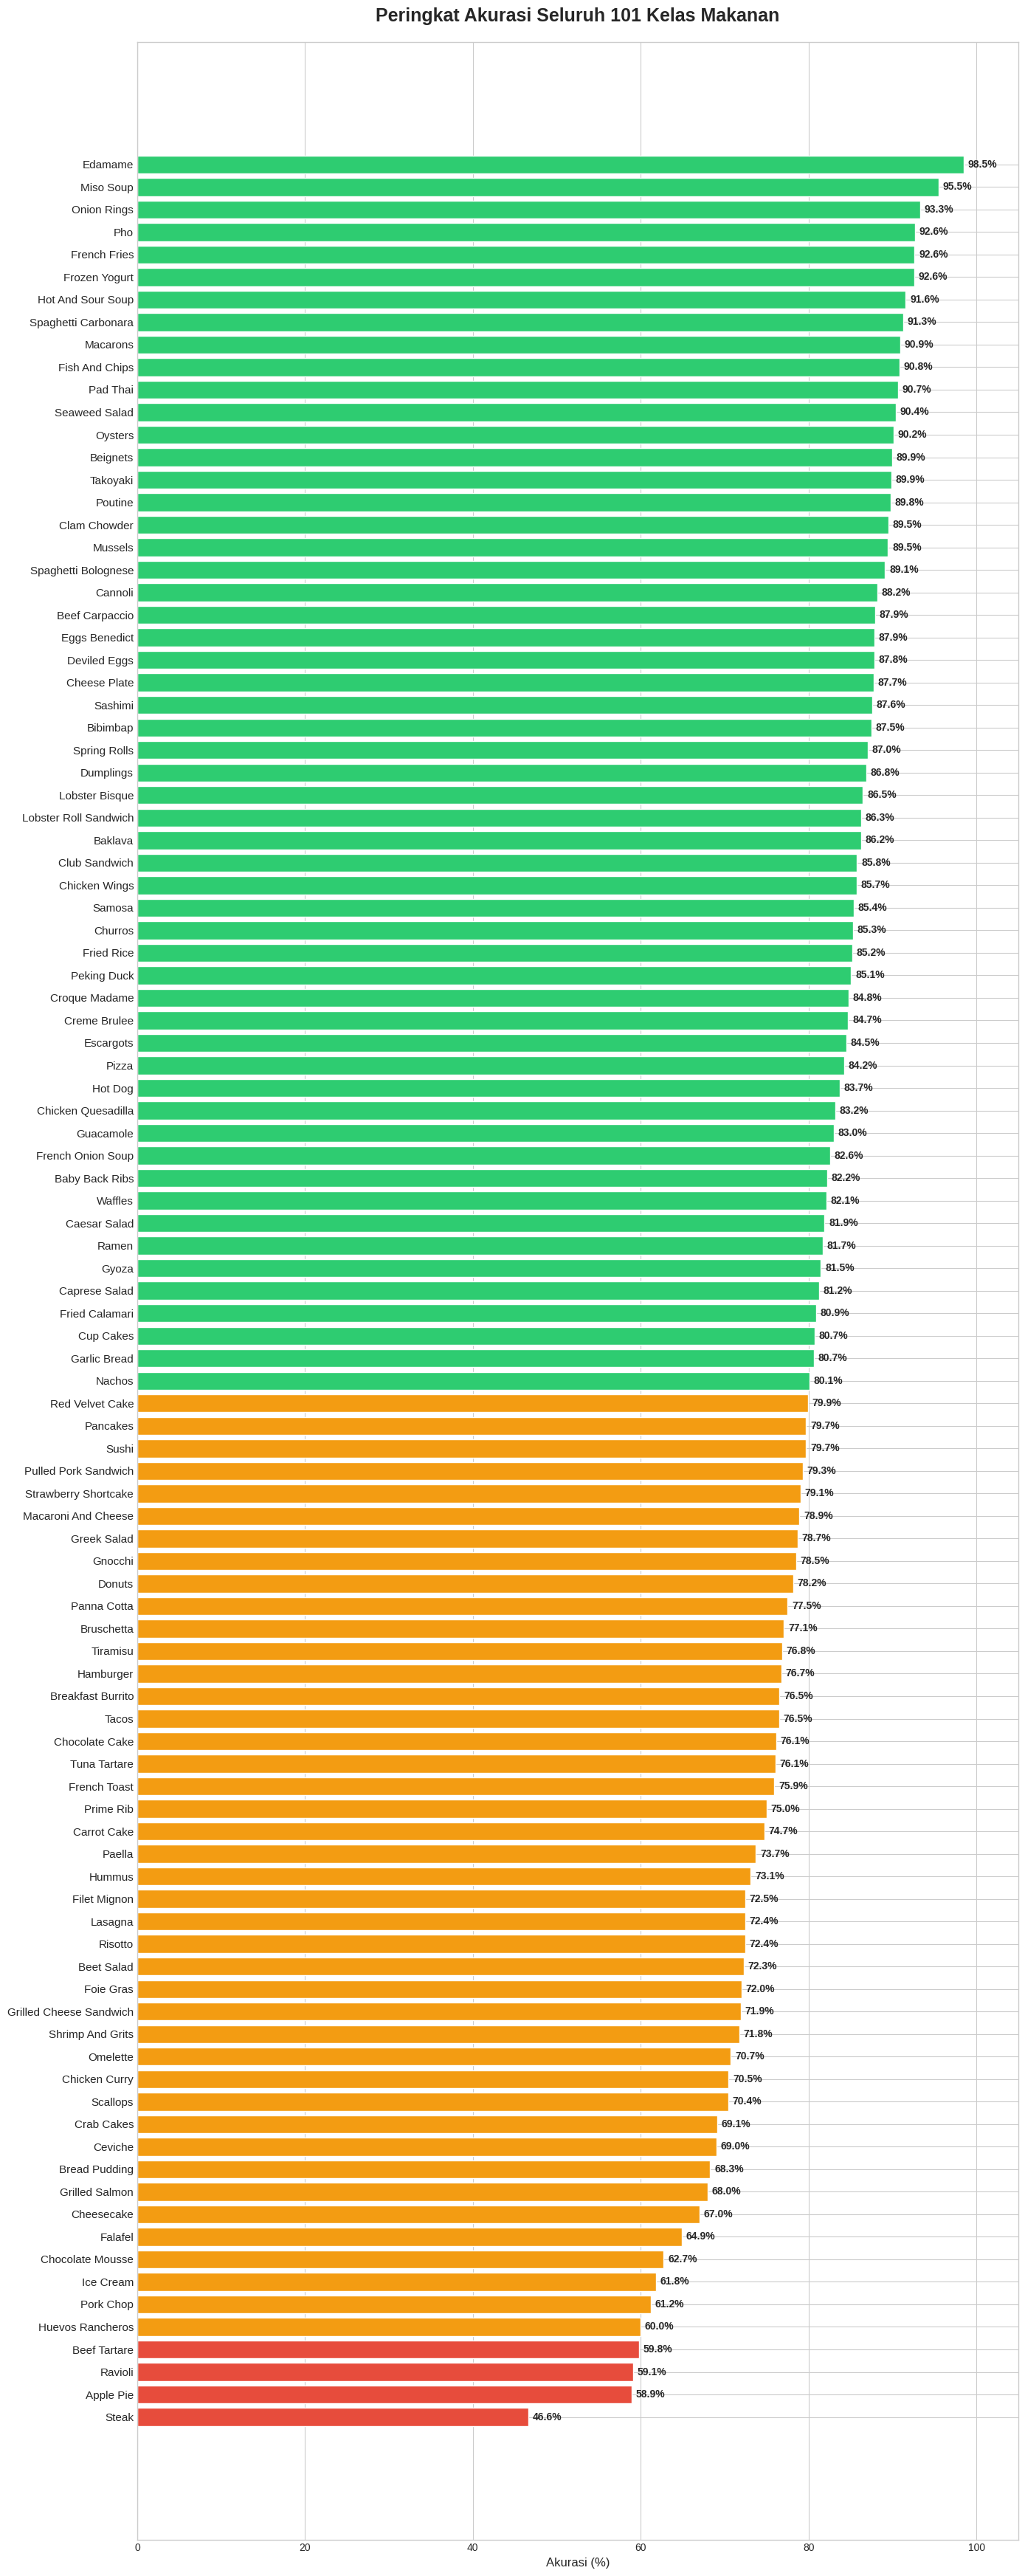

In [14]:
# @title 11. Peringkat Akurasi Seluruh 101 Kelas
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]
total_classes = len(all_acc)

# Buat figure dengan 1 kolom dan tinggi yang sangat panjang (misal: lebar 14, tinggi 35)
fig, ax = plt.subplots(figsize=(14, 35))

# Tentukan warna (Hijau >= 80%, Oranye 60-79%, Merah < 60%)
colors = ['#2ecc71' if a >= 80 else '#f39c12' if a >= 60 else '#e74c3c' for a in all_acc]

# Buat bar chart horizontal
bars = ax.barh(range(total_classes), all_acc, color=colors, edgecolor='white')

# Set label sumbu Y dengan nama-nama kelas makanan
ax.set_yticks(range(total_classes))
ax.set_yticklabels(all_names, fontsize=11)
ax.set_xlabel('Akurasi (%)', fontsize=12)
ax.set_title(f'Peringkat Akurasi Seluruh {total_classes} Kelas Makanan', fontsize=18, fontweight='bold', pad=20)
ax.set_xlim(0, 105)

# Balik sumbu Y agar peringkat 1 berada di paling atas
ax.invert_yaxis()

# Tambahkan label teks persentase di ujung kanan setiap bar
for bar, val in zip(bars, all_acc):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

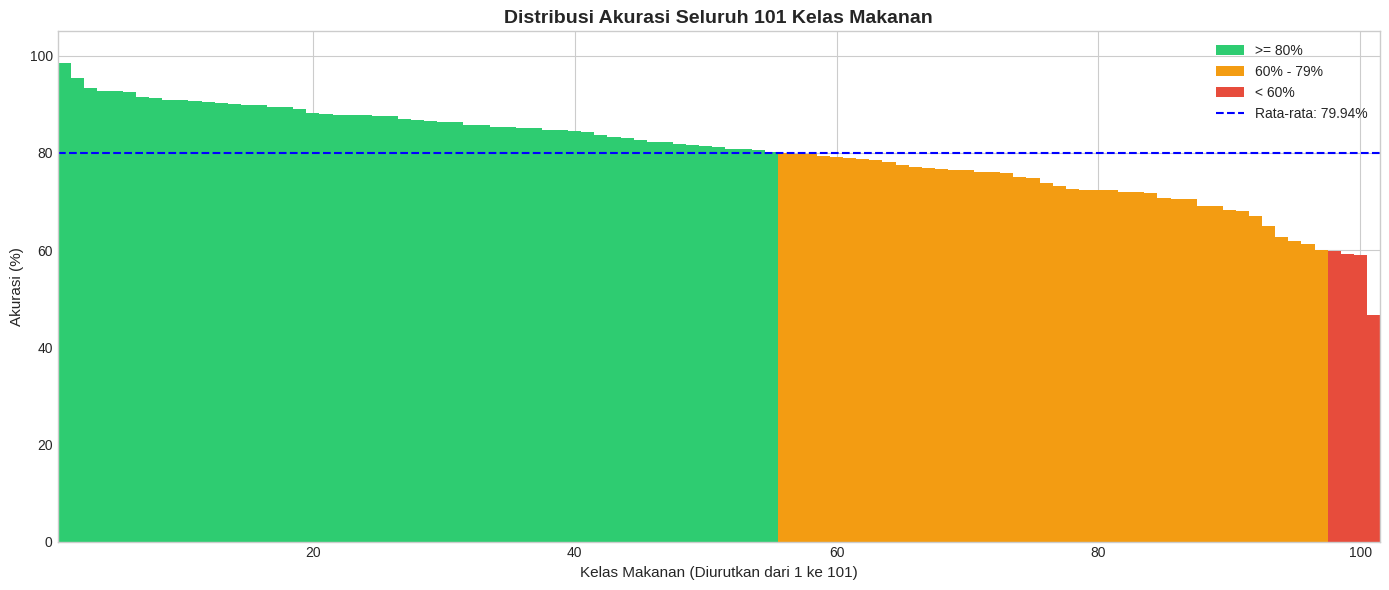

In [15]:
# @title 12. Distribusi Akurasi Seluruh Kelas
fig, ax = plt.subplots(figsize=(14, 6))

all_acc_sorted = np.sort(per_class_accuracy * 100)[::-1]
colors = ['#2ecc71' if a >= 80 else '#f39c12' if a >= 60 else '#e74c3c' for a in all_acc_sorted]

# UBAH DI SINI: Gunakan range(1, 102) agar dimulai dari 1
ax.bar(range(1, len(all_acc_sorted) + 1), all_acc_sorted, color=colors, width=1.0, edgecolor='none')

rata_rata = np.mean(per_class_accuracy) * 100
ax.axhline(y=rata_rata, color='blue', linestyle='--', linewidth=1.5, label=f'Rata-rata: {rata_rata:.2f}%')

ax.set_xlabel('Kelas Makanan (Diurutkan dari 1 ke 101)', fontsize=11)
ax.set_ylabel('Akurasi (%)', fontsize=11)
ax.set_title(f'Distribusi Akurasi Seluruh {len(all_acc_sorted)} Kelas Makanan', fontsize=14, fontweight='bold')

# UBAH DI SINI: Geser limit sumbu X
ax.set_xlim(0.5, len(all_acc_sorted) + 0.5)
ax.set_ylim(0, 105)

# Legenda warna
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='>= 80%'),
    Patch(facecolor='#f39c12', label='60% - 79%'),
    Patch(facecolor='#e74c3c', label='< 60%')
]
ax.legend(handles=legend_elements + [ax.get_lines()[0]], loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# @title 13. Konversi Final ke TensorFlow.js (EfficientNet Transplant + File Check)
import os
import shutil
import json
import tensorflow as tf
import keras # Keras 3
from zipfile import ZipFile

# --- 1. SETUP ---
print("📦 Menginstall library konverter...")
os.system('pip install -q tensorflowjs tf_keras')
import tf_keras # Keras 2 Legacy

if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)
saved_model_path = os.path.join(MODELS_DIR, 'legacy_saved_model_folder')
OUTPUT_PACKAGE_DIR = os.path.join(MODELS_DIR, 'tfjs_output_folder')
ZIP_PATH = os.path.join(MODELS_DIR, 'model_website_siap_pakai.zip')

# --- 2. DEFINISI WADAH LEGACY (EFFICIENTNET) ---
def build_legacy_model(num_classes):
    print("🏗️ Membangun Arsitektur Legacy (EfficientNetV2B0)...")
    inputs = tf_keras.Input(shape=(224, 224, 3))

    # Arsitektur harus SAMA PERSIS dengan Cell 4
    base_model = tf_keras.applications.EfficientNetV2B0(
        include_top=False,
        input_tensor=inputs,
        weights=None # Bobot akan dicopy manual
    )

    x = base_model.output
    x = tf_keras.layers.GlobalAveragePooling2D()(x)
    x = tf_keras.layers.BatchNormalization()(x)
    x = tf_keras.layers.Dropout(0.2)(x)
    outputs = tf_keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return tf_keras.Model(inputs, outputs)

# --- 3. EKSEKUSI TRANSPLANTASI ---
if 'loaded_class_names' in globals() and 'model' in globals():
    try:
        # A. Buat Wadah
        legacy_model = build_legacy_model(len(loaded_class_names))

        # B. Salin Otak (Weights)
        print("⚖️ Menyalin bobot model Keras 3 ke Keras 2...")
        legacy_model.set_weights(model.get_weights())

        # C. Simpan Legacy
        if os.path.exists(saved_model_path): shutil.rmtree(saved_model_path)
        legacy_model.save(saved_model_path, save_format='tf')
        print(f"📁 Model Legacy tersimpan di: {saved_model_path}")

        # D. Convert
        print("🚀 Mengonversi ke TensorFlow.js...")
        if os.path.exists(OUTPUT_PACKAGE_DIR): shutil.rmtree(OUTPUT_PACKAGE_DIR)
        os.makedirs(OUTPUT_PACKAGE_DIR)

        # Classes JSON
        with open(os.path.join(OUTPUT_PACKAGE_DIR, 'classes.json'), 'w') as f:
            json.dump(loaded_class_names, f)

        # Command
        cmd = f"""tensorflowjs_converter \
            --input_format=tf_saved_model \
            --output_format=tfjs_graph_model \
            --weight_shard_size_bytes=4000000 \
            --quantize_float16=* \
            --skip_op_check \
            --strip_debug_ops=True \
            "{saved_model_path}" \
            "{OUTPUT_PACKAGE_DIR}"
        """

        if os.system(cmd) == 0:
            print("✅ KONVERSI SUKSES!")

            # --- CEK FILE (YANG ANDA MINTA) ---
            print("\n📋 DAFTAR FILE YANG DIHASILKAN:")
            files_found = os.listdir(OUTPUT_PACKAGE_DIR)
            for f in files_found:
                print(f"   📄 {f}")

            # E. Zipping
            print("\n📦 Membungkus file ZIP...")
            with ZipFile(ZIP_PATH, 'w') as zipf:
                for root, dirs, files in os.walk(OUTPUT_PACKAGE_DIR):
                    for file in files:
                        zipf.write(os.path.join(root, file), file)

                nutri_path = os.path.join(MODELS_DIR, 'nutrition.json')
                if os.path.exists(nutri_path):
                    zipf.write(nutri_path, 'nutrition.json')
                    print("   ➕ nutrition.json ditambahkan.")

            print(f"\n🎉 SELESAI! Download file ini untuk Website: {ZIP_PATH}")
        else:
            print("❌ Konversi Gagal.")

    except Exception as e:
        print(f"❌ Error: {e}")
else:
    print("⚠️ Harap jalankan training dulu (Cell 6).")

📦 Menginstall library konverter...
🏗️ Membangun Arsitektur Legacy (EfficientNetV2B0)...
⚖️ Menyalin bobot model Keras 3 ke Keras 2...


📁 Model Legacy tersimpan di: /content/drive/MyDrive/Skripsi/Deep_Learning/models/legacy_saved_model_folder
🚀 Mengonversi ke TensorFlow.js...
✅ KONVERSI SUKSES!

📋 DAFTAR FILE YANG DIHASILKAN:
   📄 classes.json
   📄 group1-shard1of3.bin
   📄 group1-shard2of3.bin
   📄 group1-shard3of3.bin
   📄 model.json

📦 Membungkus file ZIP...
   ➕ nutrition.json ditambahkan.

🎉 SELESAI! Download file ini untuk Website: /content/drive/MyDrive/Skripsi/Deep_Learning/models/model_website_siap_pakai.zip


In [ ]:
# @title 14. Konversi CSV Nutrisi ke JSON (Strict 100 gram)
import os
import json
import pandas as pd

# Path
CSV_PATH = os.path.join(MODELS_DIR, 'nutrition.csv')
JSON_PATH = os.path.join(MODELS_DIR, 'nutrition.json')
CLASSES_PATH = os.path.join(META_DIR, 'classes.txt')

def convert_nutrition_100g_only():
    """
    Konversi nutrition.csv → nutrition.json.
    HANYA mengambil baris dengan weight == 100 (per 100 gram).
    Baris lain (takaran selain 100g) DIABAIKAN / tidak disimpan,
    karena deskripsi gizi di aplikasi hanya membutuhkan standar per-100g.
    """
    print("🔄 Konversi Nutrisi (STRICT 100 gram)...")

    # --- A. Load daftar kelas ---
    if os.path.exists(CLASSES_PATH):
        with open(CLASSES_PATH, 'r') as f:
            valid_classes = [line.strip() for line in f.readlines() if line.strip()]
    else:
        valid_classes = loaded_class_names if 'loaded_class_names' in globals() else []

    if not valid_classes:
        print("❌ Daftar kelas tidak ditemukan.")
        return {}

    # --- B. Load CSV nutrisi ---
    if not os.path.exists(CSV_PATH):
        print(f"❌ {CSV_PATH} tidak ditemukan. JSON tidak dibuat.")
        return {}

    df = pd.read_csv(CSV_PATH)
    print(f"📄 Total baris CSV (sebelum filter): {len(df)}")

    # --- C. FILTER: Hanya baris dengan weight == 100 ---
    df_100g = df[df['weight'] == 100].copy()
    print(f"✅ Baris dengan weight=100g: {len(df_100g)}")
    print(f"🗑️  Baris dengan weight != 100g dihapus: {len(df) - len(df_100g)}")

    if df_100g.empty:
        print("❌ Tidak ada baris dengan weight=100 di CSV. JSON tidak dibuat.")
        return {}

    # Normalisasi label untuk matching
    df_100g['clean_label'] = df_100g['label'].astype(str).str.lower().str.strip().str.replace(' ', '_')

    # --- D. Build JSON database ---
    nutrition_db = {}
    missing_classes = []

    for cls in valid_classes:
        key = cls.lower().replace(' ', '_')
        match = df_100g[df_100g['clean_label'] == key]

        if not match.empty:
            row = match.iloc[0]
            nutrition_db[cls] = {
                'kalori':       str(row['calories']),
                'protein':      str(row['protein']),
                'lemak':        str(row['fats']),
                'karbohidrat':  str(row['carbohydrates']),
                'takaran':      '100g'
            }
        else:
            # Kelas tanpa data 100g → placeholder
            nutrition_db[cls] = {
                'kalori':      '-',
                'protein':     '-',
                'lemak':       '-',
                'karbohidrat': '-',
                'takaran':     '100g'
            }
            missing_classes.append(cls)

    # --- E. Simpan ke JSON ---
    with open(JSON_PATH, 'w', encoding='utf-8') as f:
        json.dump(nutrition_db, f, indent=2, ensure_ascii=False)

    print(f"\n✅ SUKSES! File JSON tersimpan: {JSON_PATH}")
    print(f"📊 Total kelas di JSON: {len(nutrition_db)}")
    print(f"✔️  Kelas dengan data 100g: {len(nutrition_db) - len(missing_classes)}")
    if missing_classes:
        print(f"⚠️  Kelas TANPA data 100g (placeholder '-'): {len(missing_classes)}")
        print(f"   Contoh: {missing_classes[:5]}{'...' if len(missing_classes) > 5 else ''}")

    return nutrition_db

# Eksekusi
nutrition_db = convert_nutrition_100g_only()

# Preview 3 entri pertama
print("\n📋 Preview 3 entri pertama nutrition.json:")
for k, v in list(nutrition_db.items())[:3]:
    print(f"   {k}: {v}")

📸 Silakan Upload Foto Makanan dari Komputer Anda...


Saving beignets.jpg to beignets.jpg


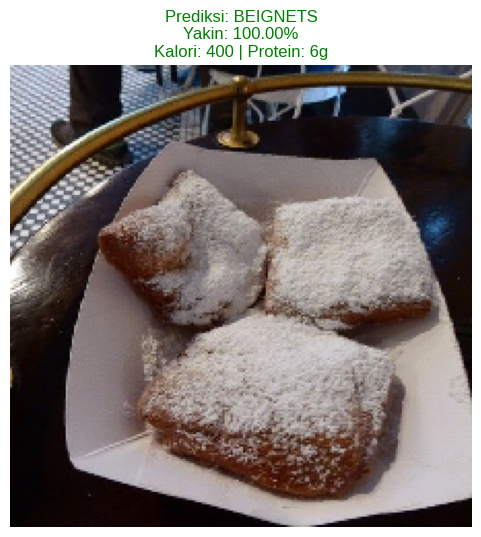

✅ File: beignets.jpg -> beignets (100.00%)


In [18]:
# @title 15. Uji Coba dengan Foto Asli (Upload Sendiri)
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def predict_custom_image():
    print("📸 Silakan Upload Foto Makanan dari Komputer Anda...")
    uploaded = files.upload()

    if not uploaded:
        print("⚠️ Tidak ada file yang diupload.")
        return

    for fn in uploaded.keys():
        path = fn
        try:
            # FIX: Pakai tf.keras.utils
            img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
            x = tf.keras.utils.img_to_array(img)
            x = np.expand_dims(x, axis=0)

            predictions = model.predict(x, verbose=0)

            pred_idx = np.argmax(predictions[0])
            pred_label = loaded_class_names[pred_idx]
            confidence = np.max(predictions[0]) * 100

            # Ambil Info Nutrisi (Butuh Cell 13 dijalankan dulu)
            info = nutrition_db.get(pred_label, {})

            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.axis('off')

            title_text = f"Prediksi: {pred_label.replace('_', ' ').upper()}\n"
            title_text += f"Yakin: {confidence:.2f}%\n"
            if info.get('kalori') != '-':
                title_text += f"Kalori: {info.get('kalori')} | Protein: {info.get('protein')}g"

            plt.title(title_text, color='green' if confidence > 70 else 'red')
            plt.show()

            print(f"✅ File: {fn} -> {pred_label} ({confidence:.2f}%)")

        except Exception as e:
            print(f"❌ Gagal memproses gambar {fn}: {e}")

predict_custom_image()

In [19]:
# @title 16. Cek Spesifikasi Lingkungan (Clean Output & Save to Drive)
import sys
import platform
import subprocess
import os
import logging

# --- SILENCE LOGS (Membungkam Iklan YDF) ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF logs
logging.getLogger('tensorflow').setLevel(logging.ERROR)
# Mematikan stdout sementara saat import tensorflowjs agar bersih
from contextlib import redirect_stdout, redirect_stderr
import io

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    import tensorflow as tf
    try:
        import tf_keras
    except: pass
    try:
        import tensorflowjs
    except: pass

print("="*60)
print("📋 SPESIFIKASI LINGKUNGAN PENGEMBANGAN")
print("="*60)

print(f"✅ Python Version      : {sys.version.split()[0]}")
print(f"✅ TensorFlow          : {tf.__version__}")
print(f"✅ Keras (Native)      : {tf.keras.__version__}")

if 'tf_keras' in sys.modules:
    print(f"✅ TF-Keras (Legacy)   : {tf_keras.__version__}")

if 'tensorflowjs' in sys.modules:
    print(f"✅ TensorFlow.js Conv. : {tensorflowjs.__version__}")

print("-" * 60)
print("📝 Membuat file requirements.txt...")

# PATH TUJUAN (LANGSUNG KE DRIVE)
REQ_PATH = os.path.join(MODELS_DIR, 'requirements.txt')

try:
    reqs = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'])
    with open(REQ_PATH, 'wb') as f:
        f.write(reqs)
    print(f"✅ SUKSES! File tersimpan di Google Drive.")
    print(f"📂 Lokasi: {REQ_PATH}")
except Exception as e:
    print(f"❌ Gagal: {e}")

📋 SPESIFIKASI LINGKUNGAN PENGEMBANGAN
✅ Python Version      : 3.12.13
✅ TensorFlow          : 2.19.0
✅ Keras (Native)      : 3.13.2
✅ TF-Keras (Legacy)   : 2.19.0
✅ TensorFlow.js Conv. : 4.22.0
------------------------------------------------------------
📝 Membuat file requirements.txt...
✅ SUKSES! File tersimpan di Google Drive.
📂 Lokasi: /content/drive/MyDrive/Skripsi/Deep_Learning/models/requirements.txt
